# Work Planning Prototype

**Background**: In our previous notebooks, we have a collection of techniques for performing, allocating, and analyzing our work. We anticipate that the scope of work will be greater than our hardware's ability to complete in a single charge. We should therefore carefully plan the work we aim to do in advance of arriving at a work site so that we come much more prepared.


Perhaps we follow a plan like:
- Prepare region image
    - Consolidate to single geotiff
    - Re-project CRS
    - Filter, smooth, simplify, downsample
- Parition region into manageable pieces
    - Call them "work areas/sites/plots", e.g. 1/2 acre spaces
- Segmentation & masking?
- Plan macro/micro routes
    - Macro: 1/2 acre work spaces
    - Micro: route between plants in a work space
- Execute? Store execution results? Analyze performance?


## Prepare Region Image

- Consolidate to single geotiff
- Reproject CRS
- Image pre-processing

In [13]:
import sys
from pathlib import Path

# Add the parent directory to the Python path
# So we can find local modules e.g. "plant_search"
sys.path.append(str(Path.cwd().parent))

# file_path = 'input/ESPG-4326-orthophoto.tif'
# file_path = 'input/MADRID_RGB.tif'
# file_path = '../input/aerial-trees.jpg'

# file_path = '../input/DJI_0010.JPG'
# file_path = '../input/DJI_0015.JPG'
# file_path = '../input/DJI_0093.JPG'
# file_path = '../input/DJI_0119.JPG'

# file_path = '../input/IGNORE_Brewster-ortho.tif'
file_path = '../input/IGNORE_Brewster-2024-all-orthophoto-UTM-32613.tif'


Image CRS - EPSG:32613


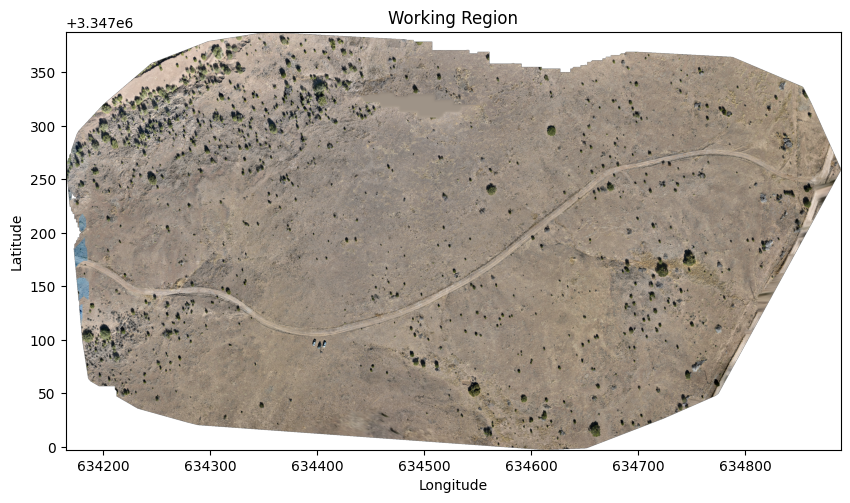

Image dimensions: (1768, 3280, 4)


In [14]:
from plant_search.load_image import load_image, plot_image, plot_geotiff

ds = 4 # downscale ratio

image, transform, bounds, image_crs = load_image(file_path)

# We have a georeferenced image
if image is not None and transform and bounds:
    original_image_shape = image.shape
    image = image[::ds, ::ds]
    # Calculate extent in geographic coordinates
    image_extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]
    plot_geotiff(image, transform, bounds, "Working Region")

# We have image, but not georeferenced
elif image is not None and bounds:
    original_image_shape = image.shape
    height, width = image.shape[:2]
    image_extent = (0, width, 0, height)
    image = image[::ds, ::ds]
    plot_image(image, "Original Image")

print(f"Image dimensions: {image.shape}")

## Parition Region
- Create outline polygon of full work region
    - Simplify geometry for faster execution
- Divide full region into working areas

In [15]:
region_crs = 32613 # Use this everywhere for consistency

simplification_tolerance = 5

# Convert target area to square meters
target_area_acres = 0.5
# target_area_acres = 5

max_iterations = 15

Reached maximum iterations without full convergence.


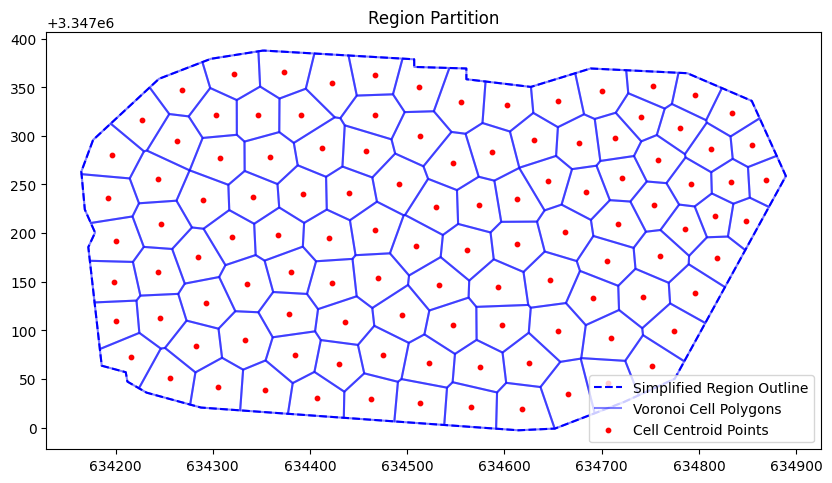

In [16]:
from plant_search.region_partition import (
    extract_region_contour,
    simplify_polygon,
    generate_voronoi_partition,
    centroidal_voronoi_tessellation,
)
import matplotlib.pyplot as plt
import geopandas as gpd


region_contour_gpd = extract_region_contour(file_path)
contour_gdf_projected = region_contour_gpd.to_crs(epsg=region_crs)  # Example: UTM Zone 14N
simplified_polygon = simplify_polygon(contour_gdf_projected.geometry.iloc[0], simplification_tolerance)

target_area_sqm = target_area_acres * 4046.86
num_points = int(simplified_polygon.area / target_area_sqm)

# voronoi_gdf, points_gdf = generate_voronoi_partition(simplified_polygon, num_points)
cell_gdf = centroidal_voronoi_tessellation(simplified_polygon, num_points, max_iterations)


fig, ax = plt.subplots(figsize=(10, 10))

gpd.GeoDataFrame({"geometry": [simplified_polygon]}).boundary.plot(ax=ax, color="blue", linestyle="--", label="Simplified Region Outline")
cell_gdf.boundary.plot(ax=ax, color="blue", alpha=0.5, label="Voronoi Cell Polygons")
cell_gdf.set_geometry('cell_centroid').plot(ax=ax, color="red", markersize=10, label="Cell Centroid Points")

plt.legend()
plt.title("Region Partition")
plt.show()

## Macro Planning

Since we have divided our working region into smaller, more manageable portions, we can now plan our approach. We will use our cells to help measure area completion and divide work areas more efficiently. 

This section is concerned with:
- clustering of cells into trips
- prioritization of cells
- global trip efficiency
    - A.K.A. Multi-Trip Routing Problem (MTRP)
- Completion efficiency

Our planning inputs:
- cells and centroids
- base station location
    - where drones launch and land
- drone battery range
- target density per cell

In [17]:
from shapely.geometry import Point
import geopandas as gpd

# Cells
# points_gdf

# Base station location
base_station_coords = (634500,3347200)
base_station_gdf = gpd.GeoDataFrame(
    [{'geometry': Point(base_station_coords)}],
    crs=region_crs
)

# Drone battery range
trip_range = 500 # meters

# Cell densities


In [18]:
from plant_search.image_preprocess import (
    generate_target_mask,
    correct_binary_mask,
    identify_targets,
)
import rasterio

# binary_mask = generate_target_mask(image) # Generate

# Load mask the easy way
binary_mask_path = "../outputs/region_binary_mask.tif"
with rasterio.open(binary_mask_path) as src:
    binary_mask = src.read(1)  # Read the first band
    bin_transform = src.transform  # Get the affine transform
    bin_crs = src.crs  # Get the CRS

full_binary_mask = correct_binary_mask(binary_mask, original_image_shape)
targets_gdf = identify_targets(full_binary_mask, transform)


del full_binary_mask # Gimme back my RAM
print(f"Number of targets (detected plants): {len(targets_gdf)}")

Number of targets (detected plants): 606


In [19]:
# # Instead of re-computing, save to image
# binary_mask_scaled = (binary_mask * 255).astype("uint8")

# with rasterio.open(file_path) as src:
#     image_region_crs = src.crs

# # Save the georeferenced binary mask with the correct scaling
# with rasterio.open(
#     "../outputs/region_binary_mask.tif",
#     "w",
#     driver="GTiff",
#     height=binary_mask.shape[0],
#     width=binary_mask.shape[1],
#     count=1,
#     dtype="uint8",
#     crs=image_region_crs,
#     transform=transform,
# ) as dst:
#     dst.write(binary_mask_scaled, 1)

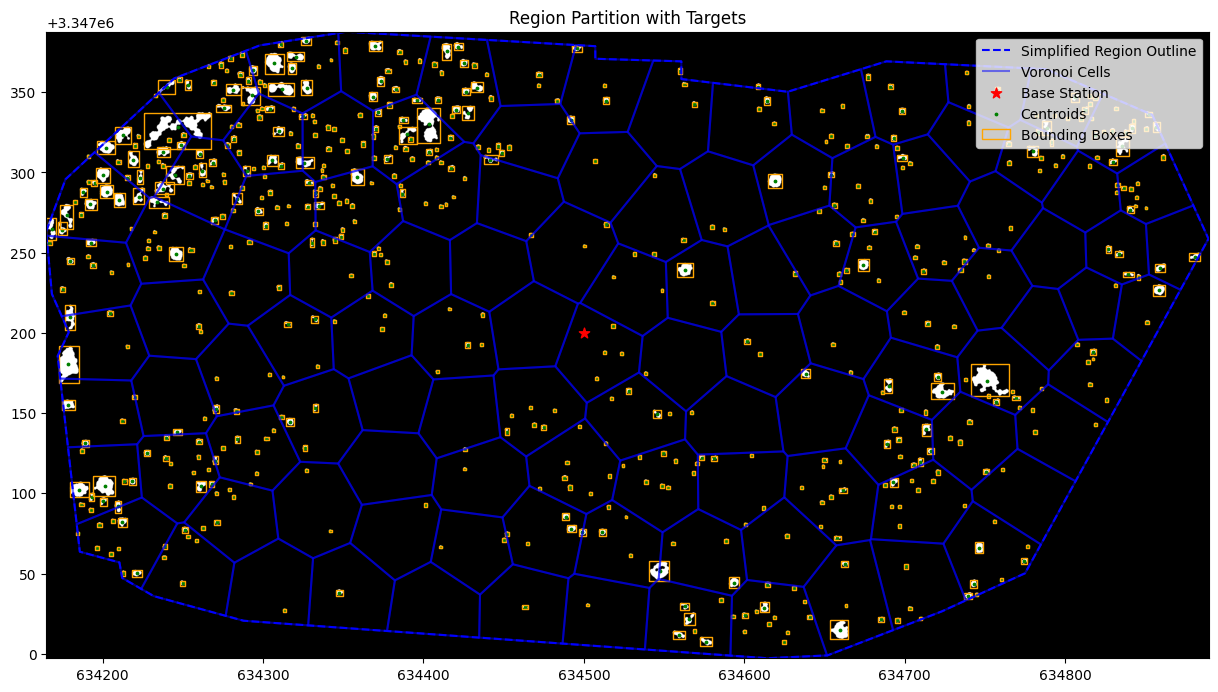

In [20]:
import matplotlib.patches as mpatches

# Display identified targets
fig, ax = plt.subplots(figsize=(15, 15))
# ax.imshow(image, extent=image_extent, alpha=0.8) # Display original image
ax.imshow(binary_mask, extent=image_extent, cmap='gray') # Show targets binary mask

# Region outline, cells, centroids
gpd.GeoDataFrame({"geometry": [simplified_polygon]}).boundary.plot(ax=ax, color="blue", linestyle="--", label="Simplified Region Outline")
cell_gdf.boundary.plot(ax=ax, color="blue", alpha=0.5, label="Voronoi Cells") # Region cells
# cell_gdf.set_geometry('cell_centroid').plot(ax=ax, color="red", markersize=10, label="Cell Centroids")
base_station_gdf.plot(ax=ax, color='red', markersize=60, marker='*', label='Base Station')

targets_gdf.plot(ax=ax, color='green', markersize=3, label='Centroids') # Plot targets centroids
targets_gdf.set_geometry('bounding_box').plot(ax=ax, edgecolor='orange', facecolor='none', linewidth=1.0) # Plot targets bounding boxes

# Fix legend for bounding boxes
handles, labels = ax.get_legend_handles_labels()
bounding_box_patch = mpatches.Patch(edgecolor='orange', facecolor='none', label='Bounding Boxes') # Add a custom handle for the bounding boxes
handles.append(bounding_box_patch)
labels.append('Bounding Boxes')

ax.legend(handles, labels, loc='upper right')
# plt.legend()
plt.title("Region Partition with Targets")
plt.show()

### Calculate Cell Densities

First-pass system to determine:
- Number of targets in each cell
- Distance to traverse all targets in each cell

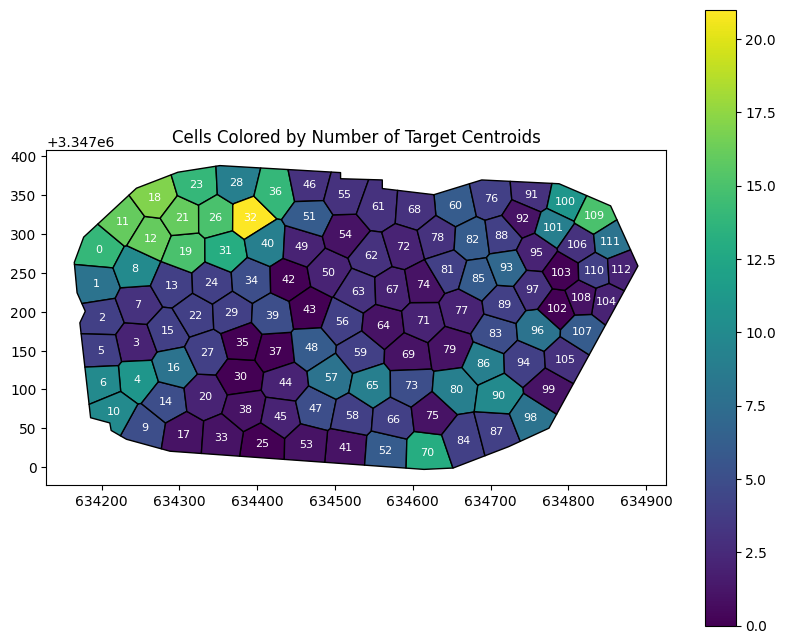

In [21]:
from plant_search.macro_planning import (
    calculate_cell_workloads,
    plot_cells_with_targets,
    plot_cells_ids,
)


calculate_cell_workloads(cell_gdf, targets_gdf) # In-place updates

# Ensure base station is a valid Point geometry

# Compute distance from each cell centroid to the base station
base_station_point = base_station_gdf.geometry.iloc[0]
cell_gdf['home_distance'] = cell_gdf['cell_centroid'].distance(base_station_point)
cell_gdf['total_workload'] = cell_gdf['intra_workload'] + (2 * cell_gdf['home_distance'])

# Visualize cell workloads
# plot_cells_with_targets(cell_gdf)
plot_cells_ids(cell_gdf)

# targets_gdf
# joined
# cell_gdf

### OR-Tools Trip Planning

This is a complete PIA to understand, but I am relatively confident this constraint solver is exactly what we need.

In [62]:
import matplotlib.pyplot as plt
import numpy as np
from shapely.geometry import LineString
import geopandas as gpd

def plot_distance_matrix(distance_matrix, title="Distance Matrix"):
    """
    Plots the distance matrix as a heatmap.

    Args:
        distance_matrix (np.ndarray): The 2D array of distances between nodes.
        title (str): Title for the plot.
    """
    plt.figure(figsize=(10, 8))
    plt.imshow(distance_matrix, cmap='viridis', interpolation='nearest')
    plt.colorbar(label='Distance')
    plt.title(title)
    plt.xlabel('Node Index')
    plt.ylabel('Node Index')
    plt.xticks(range(distance_matrix.shape[0]))
    plt.yticks(range(distance_matrix.shape[1]))
    plt.show()



def plot_centroids_and_distances(cell_gdf, distance_matrix, region_polygon, base_station_gdf, title="Centroids and Routes"):
    """
    Plots centroids and draws lines with distances between each pair of centroids.

    Args:
        cell_gdf (GeoDataFrame): GeoDataFrame with a 'geometry' column containing centroids.
        distance_matrix (np.ndarray): 2D array of distances between centroids.
        title (str): Title for the plot.
    """
    fig, ax = plt.subplots(figsize=(12, 10))
    gpd.GeoDataFrame({"geometry": [region_polygon]}).boundary.plot(ax=ax, color="blue", linestyle="--", label="Simplified Region Outline")
    cell_gdf.boundary.plot(ax=ax, color="blue", alpha=0.5, label="Voronoi Cells") # Region cells
    base_station_gdf.plot(ax=ax, color='red', markersize=60, marker='*', label='Base Station')
    

    # Plot centroids
    for i, centroid in enumerate(cell_gdf.cell_centroid):
        ax.scatter(centroid.x, centroid.y, color='blue', s=50, label='Centroid' if i == 0 else "")
        ax.text(centroid.x, centroid.y, str(i), fontsize=10, ha='right')
    
    # Draw lines and annotate distances from base station to centroids
    base_station = base_station_gdf.geometry.iloc[0]
    base_station_index = len(cell_gdf)

    for i, centroid in enumerate(cell_gdf.cell_centroid):
        # Create a line from base station to the centroid
        line = LineString([base_station, centroid])
        ax.plot(*line.xy, color='gray', linestyle='--', linewidth=1, alpha=0.35)
        
        # Annotate the distance on the line
        midpoint = line.interpolate(0.5, normalized=True)
        distance = distance_matrix[base_station_index, i]
        ax.text(midpoint.x, midpoint.y, f"{distance:.1f}", fontsize=8, color='red', alpha=0.8)

    # # WARNING: Turns into a cluster *immediately*
    # # Draw lines and annotate distances between all cells
    # for i, centroid_i in enumerate(cell_gdf.cell_centroid):
    #     for j, centroid_j in enumerate(cell_gdf.cell_centroid):
    #         if i < j:  # Avoid duplicate lines
    #             # Create a line between centroids
    #             line = LineString([centroid_i, centroid_j])
    #             ax.plot(*line.xy, color='gray', linestyle='--', linewidth=1, alpha=0.3)
                
    #             # Annotate the distance on the line
    #             midpoint = line.interpolate(0.5, normalized=True)
    #             distance = distance_matrix[i, j]
    #             ax.text(midpoint.x, midpoint.y, f"{distance:.1f}", fontsize=6, color='red')
    
    # Title and labels
    ax.set_title(title, fontsize=16)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.legend(loc='upper right')
    plt.grid(True)
    plt.show()



import matplotlib.pyplot as plt
from shapely.geometry import LineString
import matplotlib.cm as cm
import geopandas as gpd

def plot_vrp_solution(cell_gdf, distance_matrix, region_polygon, base_station_gdf, routes, title="VRP Solution"):
    """
    Plots the VRP solution showing non-zero trips.

    Args:
        cell_gdf (GeoDataFrame): GeoDataFrame with polygon geometries.
        distance_matrix (np.ndarray): Distance matrix used in the VRP.
        region_polygon (shapely.geometry.Polygon): Polygon outlining the region.
        base_station_gdf (GeoDataFrame): GeoDataFrame containing the base station point.
        routes (list of lists): Routes for each vehicle.
        title (str): Title for the plot.
    """
    # Extract centroids
    centroids = cell_gdf.cell_centroid
    
    # Extract base station point
    base_station = base_station_gdf.geometry.iloc[0]  # Assuming single base station
    
    # Plot centroids, region outline, and base station
    fig, ax = plt.subplots(figsize=(12, 10))
    gpd.GeoDataFrame({"geometry": [region_polygon]}).boundary.plot(ax=ax, color="blue", linestyle="--", label="Simplified Region Outline")
    cell_gdf.boundary.plot(ax=ax, color="blue", linewidth=1, alpha=0.5, label="Voronoi Cells")  # Region cells
    base_station_gdf.plot(ax=ax, color='red', markersize=80, marker='*', zorder=10, label='Base Station')

    for i, centroid in enumerate(centroids):
        ax.scatter(centroid.x, centroid.y, color='blue', s=20, alpha=0.5, label='Centroid' if i == 0 else "")
        ax.text(centroid.x, centroid.y, str(i), fontsize=10, ha='right')
    
    # Generate a colormap for routes
    cmap = plt.get_cmap("tab20", len(routes))  # Tab10 provides distinct colors
    
    # Plot routes
    for route_idx, route in enumerate(routes):
        color = cmap(route_idx)  # Unique color for each route
        full_route = route + [route[0]]  # Ensure route returns to base station
        
        for i in range(len(full_route) - 1):
            from_node = full_route[i]
            to_node = full_route[i + 1]
            
            if from_node == len(centroids):  # From base station
                start_point = base_station
            else:
                start_point = centroids.iloc[from_node]
            
            if to_node == len(centroids):  # To base station
                end_point = base_station
            else:
                end_point = centroids.iloc[to_node]
            
            if distance_matrix[from_node][to_node] > 0:
                # Draw line between nodes
                line = LineString([start_point, end_point])
                ax.plot(*line.xy, color=color, linestyle='-', linewidth=2, label=f"Route {route_idx}" if i == 0 else "")
                
                # Annotate distance
                # midpoint = line.interpolate(0.5, normalized=True)
                # ax.text(midpoint.x, midpoint.y, f"{distance_matrix[from_node][to_node]:.0f}",
                #         fontsize=8, color='green')
    
    # Final plot details
    ax.set_title(title, fontsize=16)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.legend(loc='upper right', fontsize=10)
    plt.grid(True)
    plt.show()


In [49]:
import math 

def print_vehicle_details(routing, manager, solution, distance_dimension, max_distance):
    """
    Prints the objective value and each vehicle's cumulative distance, slack, and span.

    Args:
        routing (RoutingModel): OR-Tools RoutingModel instance.
        manager (RoutingIndexManager): OR-Tools RoutingIndexManager instance.
        solution (Assignment): Solution from the solver.
        distance_dimension (Dimension): Distance dimension object.
        max_distance (int): Upper bound for distance.
    """
    print("Objective Value:", solution.ObjectiveValue())
    print(f"Max allowed distance: {max_distance}")
    print("\nVehicle Details:")

    max_route_distance = 0
    min_route_distance = math.inf
    for vehicle_id in range(manager.GetNumberOfVehicles()):
        index = routing.Start(vehicle_id)
        route_distance = 0

        print(f"\nVehicle {vehicle_id}:")
        plan_output = f"\tRoute for vehicle {vehicle_id}:\n\t  "

        while not routing.IsEnd(index):
            plan_output += f" {manager.IndexToNode(index)} -> "
            previous_index = index
            index = solution.Value(routing.NextVar(index))
            route_distance += routing.GetArcCostForVehicle(
                previous_index, index, vehicle_id
            )

        plan_output += f"{manager.IndexToNode(index)}"
        print(plan_output)

        # Cumulative distance for this vehicle
        end_index = routing.End(vehicle_id)
        cumulative_distance = solution.Value(distance_dimension.CumulVar(end_index))
        slack = max(0, max_distance - cumulative_distance)

        print(f"\tCumulative Distance: {cumulative_distance}") # Cumulative = Route Distance + Slack + Penalties
        print(f"\tSlack: {slack}")
        print(f"\tRoute Distance: {route_distance}") # sum of the direct transit costs (e.g., distances) between all nodes

        max_route_distance = max(route_distance, max_route_distance)
        min_route_distance = min(route_distance, min_route_distance) if route_distance>0 else min_route_distance

    print(f"Maximum of the route distances: {max_route_distance}m")
    print(f"Minimum of the route distances: {min_route_distance}m")


In [103]:
from ortools.constraint_solver import pywrapcp, routing_enums_pb2
from plant_search.macro_planning import print_vrp_solution


def setup_distance_dimension(routing, manager, data, max_distance, penalty):
    """
    Configures the distance dimension to prioritize filling routes close to max_distance,
    leaving the remainder for the last vehicle(s).

    We want to solve routes for our target area such that:
    - We have the fewest total routes to run (fewest batteries to charge)
        - ⇒ routes must be efficient (minimize total distance across all routes)
        - ⇒ routes must be close to max_distance of drone (get the most of each charge)

    Args:
        routing (RoutingModel): The OR-Tools RoutingModel.
        manager (RoutingIndexManager): The OR-Tools RoutingIndexManager.
        transit_callback_index (int): Index of the transit callback.
        max_distance (int): Maximum allowed distance per route.
        penalty (int): Penalty per unit of unused distance below max_distance.

    Returns:
        Dimension: The configured distance dimension.
    """
    # Distance callback
    def distance_callback(from_index, to_index):
        from_node = manager.IndexToNode(from_index)
        to_node = manager.IndexToNode(to_index)
        return data["distance_matrix"][from_node][to_node]

    transit_callback_index = routing.RegisterTransitCallback(distance_callback)
    routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

    # Add the distance dimension
    distance_dimension_name = "Distance"
    routing.AddDimension(
        transit_callback_index,
        0,                       # No slack
        max_distance,            # Upper bound for distance
        True,                    # Start cumulative at zero
        distance_dimension_name
    )
    distance_dimension = routing.GetDimensionOrDie(distance_dimension_name)

    # Apply soft lower bound for all routes except the last one
    num_vehicles = manager.GetNumberOfVehicles()
    for vehicle_id in range(num_vehicles):
        end_index = routing.End(vehicle_id)
        
        if vehicle_id < num_vehicles - 1:
            # Set soft lower bound for all but the last vehicle
            distance_dimension.SetCumulVarSoftLowerBound(end_index, max_distance, penalty)
        else:
            # No lower bound for the last vehicle (flexible)
            pass

    return distance_dimension


def solve_basic_vrp(data, print_routes=False):
    # Setup OR-Tools
    manager = pywrapcp.RoutingIndexManager(
        len(data["distance_matrix"]),  # +1 for depot
        data["num_vehicles"],      # vehicles count
        data["depot"])      # Depot is at the last index

    routing = pywrapcp.RoutingModel(manager)

    # Distance callback
    def distance_callback(from_index, to_index):
        from_node = manager.IndexToNode(from_index)
        to_node = manager.IndexToNode(to_index)
        return data["distance_matrix"][from_node][to_node]

    transit_callback_index = routing.RegisterTransitCallback(distance_callback)
    routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

    # Add our distance constraint
    distance_dimension_name = "Distance"
    routing.AddDimension(
        transit_callback_index,  # Callback index
        20,                       # Slack buffer
        data["max_distance"],            # Maximum distance per vehicle
        True,                    # Start cumulative at zero
        distance_dimension_name
    )
    distance_dimension = routing.GetDimensionOrDie(distance_dimension_name) # Class RoutingDimension
    distance_dimension.SetGlobalSpanCostCoefficient(0) # Penalty for difference between longest and shortest routes

    # Penalize routes that don't use the full distance
    num_vehicles = data['num_vehicles']
    slack_vehicles = 5 # Number of vehicles NOT pushing to fill routes
    # slack_penalty = 1_000_000
    slack_penalty = 10_000
    for vehicle_id in range(manager.GetNumberOfVehicles()):
        if vehicle_id < num_vehicles - slack_vehicles:
            # Set soft lower bound for all but first N vehicles
            end_index = routing.End(vehicle_id)
            distance_dimension.SetCumulVarSoftLowerBound(end_index, data["max_distance"], slack_penalty)
        else:
            pass # No lower bound for the first N vehicles (flexible)


    # Solve the problem
    search_parameters = pywrapcp.DefaultRoutingSearchParameters()
    search_parameters.first_solution_strategy = (
        # routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
        routing_enums_pb2.FirstSolutionStrategy.PATH_MOST_CONSTRAINED_ARC
        # routing_enums_pb2.FirstSolutionStrategy.LOCAL_CHEAPEST_INSERTION
        # routing_enums_pb2.FirstSolutionStrategy.LOCAL_CHEAPEST_COST_INSERTION
    )

    # # May work, but takes forever to compute so far
    # search_parameters.local_search_metaheuristic = routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
    # search_parameters.time_limit.seconds = 240  # Adjust as needed

    solution = routing.SolveWithParameters(search_parameters)
    
    # Extract the solution
    if solution and print_routes:
        # print_vrp_solution(data, manager, routing, solution)
        print_vehicle_details(routing, manager, solution, distance_dimension, data["max_distance"])

    if solution:
        routes = []
        for vehicle_id in range(data["num_vehicles"]):
            index = routing.Start(vehicle_id)
            route = []
            while not routing.IsEnd(index):
                route.append(manager.IndexToNode(index))
                index = solution.Value(routing.NextVar(index))
            routes.append(route)
        return routes
    else:
        return "No solution found."

num_cells: 113
num_vehicles: 14
Objective Value: 7241
Max allowed distance: 800

Vehicle Details:

Vehicle 0:
	Route for vehicle 0:
	   113 ->  85 ->  93 ->  95 ->  106 ->  111 ->  109 ->  100 ->  101 ->  88 ->  81 ->  74 ->  67 -> 113
	Cumulative Distance: 800
	Slack: 0
	Route Distance: 796

Vehicle 1:
	Route for vehicle 1:
	   113 ->  69 ->  79 ->  86 ->  94 ->  99 ->  105 ->  107 ->  96 ->  83 ->  64 -> 113
	Cumulative Distance: 800
	Slack: 0
	Route Distance: 723

Vehicle 2:
	Route for vehicle 2:
	   113 ->  34 ->  24 ->  13 ->  8 ->  0 ->  1 ->  2 ->  7 ->  22 ->  29 ->  37 -> 113
	Cumulative Distance: 800
	Slack: 0
	Route Distance: 754

Vehicle 3:
	Route for vehicle 3:
	   113 ->  97 ->  103 ->  110 ->  112 ->  104 ->  108 ->  102 ->  89 ->  77 ->  71 -> 113
	Cumulative Distance: 800
	Slack: 0
	Route Distance: 781

Vehicle 4:
	Route for vehicle 4:
	   113 ->  40 ->  32 ->  28 ->  23 ->  26 ->  21 ->  18 ->  11 ->  12 ->  19 ->  31 ->  42 -> 113
	Cumulative Distance: 800
	Slack: 0


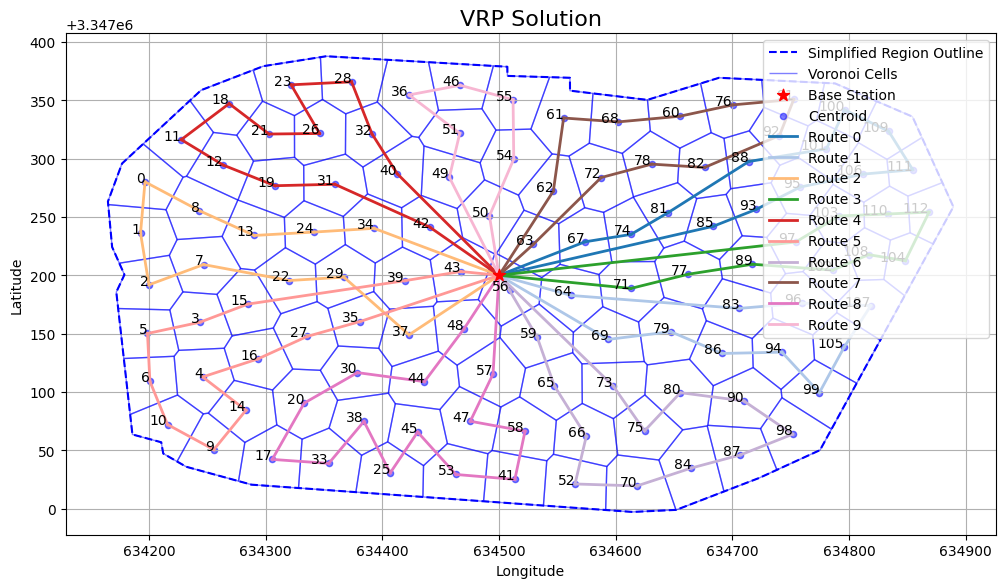

In [102]:
from plant_search.macro_planning import (
    create_distance_matrix,
    # solve_basic_vrp,
)
import math

# Input data
max_distance = 800  # Max distance per trip

# Create a distance matrix (including intra-workload cost)
distance_matrix = create_distance_matrix(cell_gdf, base_station_gdf)

# # Debugging distance matrix
# print(distance_matrix)
# print(type(distance_matrix))
# print(type(distance_matrix[0]))
# print(type(distance_matrix[0][0]))

# plot_distance_matrix(distance_matrix)
# plot_centroids_and_distances(cell_gdf, distance_matrix, simplified_polygon, base_station_gdf)

# Simple usage (debugging)
num_cells = len(distance_matrix)-1
# num_vehicles = math.ceil(math.sqrt(num_cells)) + 1
num_vehicles = 14
print(f"num_cells: {num_cells}")
print(f"num_vehicles: {num_vehicles}")

data = {}
data["distance_matrix"] = distance_matrix
data["num_vehicles"] = num_vehicles # AKA number of trips
data["depot"] = num_cells # index of depot in matrix
data["max_distance"] = max_distance

print_routes = True
routes = solve_basic_vrp(data, print_routes)

# Are we able to impose a minimum distance for a route as well?
# Downsides of imposing minimum distance?

# Span cost, max, min
# 100k, 793, 596 
# 1000, 739, 596
# 10, 794, 584
# 1, 794, 553

# # If solved, plot solution
plot_vrp_solution(cell_gdf, distance_matrix, simplified_polygon, base_station_gdf, routes)


In [25]:
def evaluate_trip_cost(trip, distance_matrix):
    """
    Evaluates the total cost of a trip.

    Args:
        trip (list): List of node indices representing the trip.
        distance_matrix (np.ndarray): The distance matrix for the problem.

    Returns:
        float: Total cost of the trip.
    """
    if len(trip) < 2:
        return 0  # No cost for empty or single-node trips

    total_cost = 0
    for i in range(len(trip) - 1):
        from_node = trip[i]
        to_node = trip[i + 1]
        total_cost += distance_matrix[from_node][to_node]

    return total_cost


def evaluate_all_trips(trips, distance_matrix):
    """
    Evaluates the total cost of all trips.

    Args:
        trips (list of lists): List of trips, where each trip is a list of node indices.
        distance_matrix (np.ndarray): The distance matrix for the problem.

    Returns:
        dict: Dictionary with trip costs and total cost.
    """
    trip_costs = []
    total_cost = 0

    for trip in trips:
        trip_cost = evaluate_trip_cost(trip, distance_matrix)
        trip_costs.append(trip_cost)
        total_cost += trip_cost

    return {
        "trip_costs": trip_costs,
        "total_cost": total_cost
    }

# costs = evaluate_all_trips(trips, d_matrix)

# print("Trip Costs:", costs["trip_costs"])
# print("Total Cost:", costs["total_cost"])

### Data Relations

Finally, after much computation, we can now begin to treat our GDFs as database tables and relate them. 

First, we attempt to associate each target with a cell.

## Micro Planning

Perform image analysis on each smaller section of our greater region.